<a href="https://colab.research.google.com/github/BaberFaisal/Quantifying-Sales-Uplift-With-Causal-Impact-Analysis/blob/main/Quantifying_Sales_Uplift_With_Causal_Impact_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Quantifying Sales Uplift With Causal Impact Analysis**

#**Table of Contents**
- Project Overview
  - Context
  - Actions
  - Results
  - Growth/Next Steps
- Causal Impact Analysis Overview
- Data Overview & Preparation
- Applying Causal Impact Analysis
- Analysing The Results

#**Project Overview**
#Context
Our client, a national grocery retailer, recently launched a new membership initiative — the “Delivery Club” — which offers unlimited free deliveries for an annual subscription fee of 100 dollars, eliminating the usual 10 dollars per delivery charge.

The central business question is whether this program has successfully driven higher customer spending in the three months following enrollment. The underlying assumption is that eliminating delivery fees might lead customers to shop more often and spend more overall.

This project aims to quantify the sales uplift generated by the Delivery Club — identifying how much more customers spent than they likely would have, had the program never launched.

#Actions
To assess this impact, we applied Causal Impact Analysis using the pycausalimpact library.

The campaign_data table provides insight into which customers received Delivery Club promotions, who were in control groups, and who eventually subscribed. However, because the offer was open to all, we chose a different approach: customers who didn’t join the club served as our control group. These customers represent what “normal” behavior would have looked like, enabling us to estimate a counterfactual trend for those who did enroll.

Sales data was sourced from the transactions table and aggregated to a daily spend per customer format, as required by the model. We selected a 3-month window before the program went live as the baseline period and used the subsequent 3 months to measure the effect.

#Results
Analysis revealed a 41.1% increase in spending among customers who joined the Delivery Club — compared to what they likely would have spent had they not enrolled. This uplift was observed over the three-month post-period and was found to be statistically significant at the 95% confidence level.

#Growth/Next Steps
There are several valuable directions for extending this analysis:

- Seasonality Adjustment: Comparing with the same three-month period from the previous year could help isolate whether any of the increase is seasonal.

- Trend Evaluation: Track changes over time to see whether the uplift:

  - Continues or accelerates

  - Plateaus

  - Diminishes due to early engagement

- Spend Composition Analysis: Investigate whether customers are spending more within existing product categories, or exploring and buying from new ones.

#**Causal Impact Analysis Overview**
#Context
A fundamental task in Data Science and Analytics involves measuring the effect of a particular event on a key business metric.

Depending on the domain, this could mean analyzing the sales uplift following a marketing promotion or product launch, the additional user engagement from a digital advertising campaign, the fluctuation in stock price following a macroeconomic announcement, or even the shift in the USD’s value after a political speech.

In all such scenarios, the core goal remains consistent: to quantify the magnitude of the impact.

However, measuring this impact rigorously requires us to determine what would have occurred if the event had not happened — in other words, we need to construct a counterfactual.

Real-world data often contains noise, volatility, and trends that fluctuate over time, making it challenging to isolate the true effect of an event. While randomized controlled trials (RCTs) offer a clean comparison between exposed and non-exposed groups, these experiments are not always practical due to cost, feasibility, or ethical constraints.

This is where Causal Impact Analysis proves highly valuable — offering a robust alternative for estimating impact without requiring a traditional experiment.

#How It Works
Causal Impact is a Bayesian time-series modeling technique initially developed by Google.

It works by analyzing data prior to an intervention (the pre-period) to understand historical trends, then uses this to forecast what would have likely occurred in the period following the event (the post-period) — this forecast is referred to as the counterfactual. The gap between the actual data and this projection represents the estimated effect of the intervention.

To build this model, we need comparable time-series data — these can be control groups, correlated variables, or multiple related time-series. However, for the model to produce valid results, the chosen data must meet two key criteria:

1. Unaffected by the intervention — the external data should not be influenced by the event we're evaluating.

2. Predictively correlated — the data should have a meaningful relationship with the primary metric of interest.

In cases where an experimental control group exists, it can be directly used. If not, alternative proxy variables that reflect related trends — but remain unaffected by the intervention — must be identified. For example:

- If assessing the impact on a stock, similar industry stocks might serve as control data.

- For evaluating sales in a category like health and beauty, sales data from another stable, unrelated category in the store might be appropriate.

The algorithm uses this additional time-series to learn the relationship patterns between them during the pre-period. Once the model understands how the input time-series influences the output, it applies these learned relationships to the post-period to generate the counterfactual forecast — predicting what would have likely occurred without the intervention.

Finally, by comparing the actual observed values with this forecast, we calculate the estimated causal effect — the difference attributable to the event.

#Application
In this analysis, we’ll use the Python library pycausalimpact, which implements this methodology. It builds the model, estimates the counterfactual, and provides informative visualizations and summary statistics to help interpret the results clearly and confidently.

#**Data Overview & Preparation**
The client’s database includes a campaign_data table that identifies which customers received different types of “Delivery Club” promotional materials, which ones were part of a control group, and who eventually enrolled in the program.

Although the built-in control group could be used to assess the effect of marketing contact, our primary goal here is to evaluate the overall impact of joining the Delivery Club on customer spending. For this reason, we define our control group as customers who did not subscribe to the club — assuming their behavior remained consistent after the launch. This group provides the foundation for estimating the counterfactual: what the spend would have looked like for subscribers if the club hadn’t existed.

In the following steps, we:

- Load the necessary Python libraries.

- Extract relevant data from both the transactions and campaign_data tables, focusing on a 3-month window before and after the campaign.

- Summarize transaction-level data from a granular customer/transaction/product area format to a daily customer/date structure.

- Incorporate the membership status by merging with the signup flag from the campaign data.

- Aggregate the data further to show daily sales totals for both subscribers and non-subscribers.

- Format the data to meet the input requirements of the pycausalimpact package.

- Rename the groups to more intuitive labels, ensuring the analysis and charts are easier to interpret.

In [ ]:
!pip install pycausalimpact # corrected package name to "pycausalimpact"

In [ ]:
# install the required python libraries
from causalimpact import CausalImpact
import pandas as pd


# extract relevant data from the transactions table
transactions = pd.read_excel('/content/grocery_database .xlsx', sheet_name='transactions')
campaign_data = pd.read_excel('/content/grocery_database .xlsx', sheet_name='campaign_data')


# aggregate transaction data to customer, date level
customer_daily_sales = transactions.groupby(["customer_id", "transaction_date"])["sales_cost"].sum().reset_index()

# merge on the signup flag
customer_daily_sales = pd.merge(customer_daily_sales, campaign_data, how = "inner", on = "customer_id")

# pivot the data to aggregate daily sales by signup group
causal_impact_df = customer_daily_sales.pivot_table(index = "transaction_date",
                                                    columns = "signup_flag",
                                                    values = "sales_cost",
                                                    aggfunc = "mean")

# provide a frequency for our DateTimeIndex (avoids a warning message)
causal_impact_df.index.freq = "D"

# ensure the impacted group is in the first column (the library expects this)
causal_impact_df = causal_impact_df[[1,0]]

# rename columns to something lear & meaningful
causal_impact_df.columns = ["member", "non_member"]
causal_impact_df.head()

,member,non_member
transaction_date,,
2020-04-01,194.488065,74.463333
2020-04-02,185.161667,75.558254
2020-04-03,118.121333,74.387353
2020-04-04,198.525357,63.003797
2020-04-05,145.456000,72.440441


#**Applying Causal Impact Analysis**

In the following code, we define the time windows for our analysis—setting the start and end dates for both the pre-intervention and post-intervention periods.

We then run the Causal Impact algorithm by providing it with the formatted DataFrame and the specified time ranges.

The algorithm uses data from the pre-period to learn the relationship between those who joined the Delivery Club and those who didn’t. It then projects this relationship into the post-period to estimate a counterfactual scenario—what the average daily spend for members would likely have been if the Delivery Club had never been introduced.

By comparing this counterfactual with the actual post-period spend, we can isolate and quantify the true effect of the Delivery Club—that is, the causal impact.

In [ ]:
# specify the pre & post periods
pre_period = ["2020-04-01","2020-06-30"]
post_period = ["2020-07-01","2020-09-30"]

# apply the algorithm
ci = CausalImpact(causal_impact_df, pre_period, post_period)

/usr/local/lib/python3.11/dist-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/usr/local/lib/python3.11/dist-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/usr/local/lib/python3.11/dist-packages/statsmodels/base/optimizer.py:19: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: nseasons, standardize. After release 0.14, this will raise.
  warnings.warn(
/usr/local/lib/python3.11/dist-packa

#**Analysing The Results**

**Plotting The Results**

The pycausalimpact library makes plotting the results extremely easy - all done with the single line of code below:

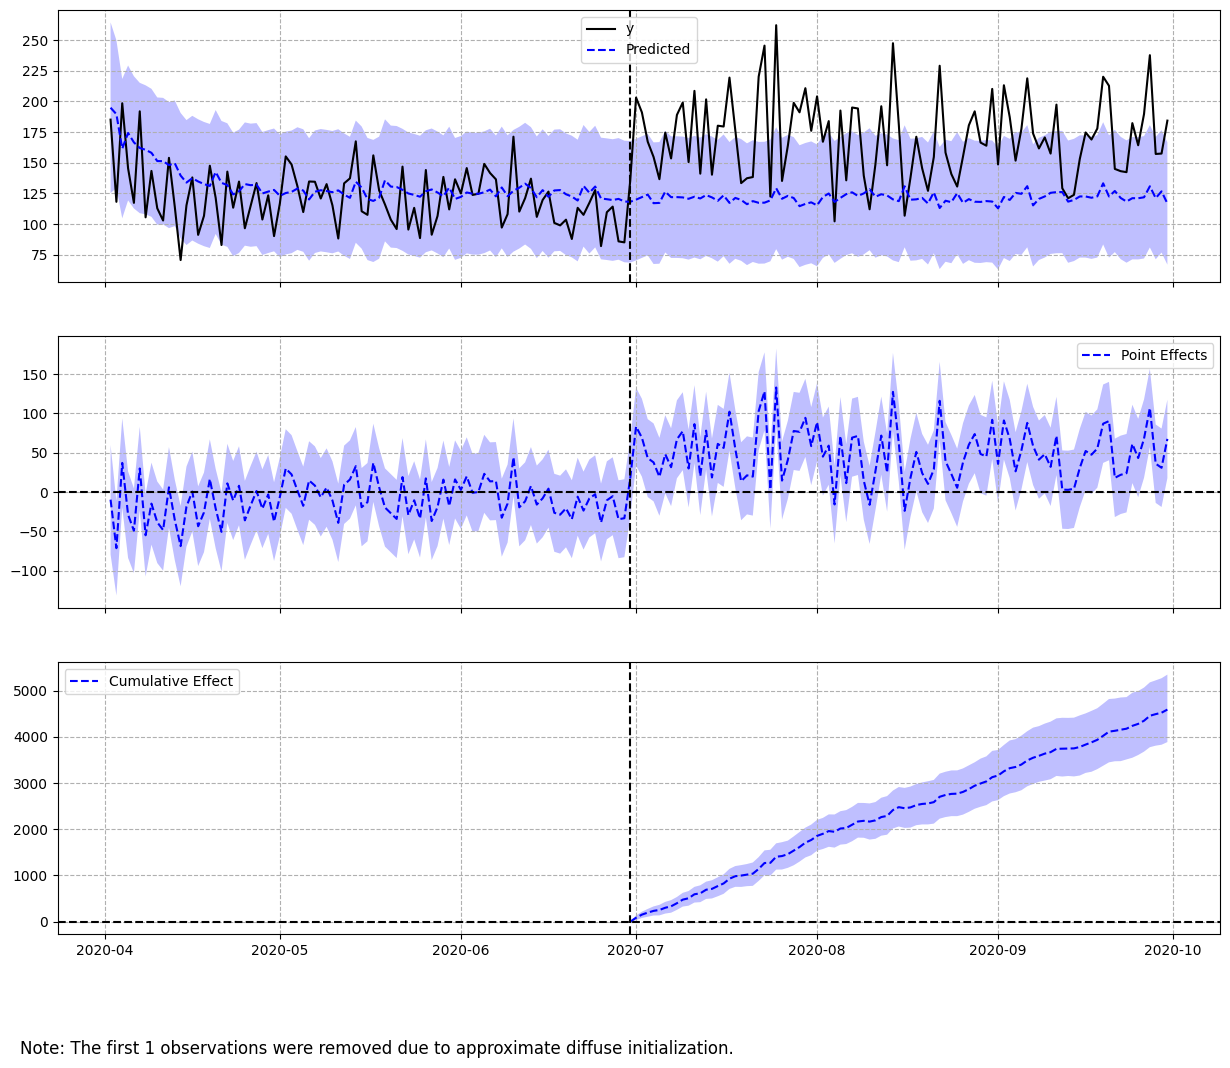

In [ ]:
# plot the results
ci.plot()


To help interpret the visual output from the Causal Impact analysis:

**Understanding the Chart Layout**

The vertical dotted line in all three charts marks the point in time when the Delivery Club membership began. The section before this line is the pre-intervention period, and the section after is the post-intervention period.

**Chart 1: Actual vs. Predicted (Counterfactual)**

The top chart compares the actual average daily sales of customers who enrolled in the Delivery Club (shown by the black line) with the predicted values had the club not been introduced (the blue dashed line). This prediction is called the counterfactual.

The shaded purple band around the counterfactual represents the confidence interval—the range within which the predicted values are expected to fall. A wider band reflects more uncertainty in the prediction.

Even with a quick glance, the chart suggests that post-launch, actual spending was often above the counterfactual, indicating a positive uplift in customer spending following membership.

**Chart 2: Daily Differences (Pointwise Effects)**

The middle chart highlights the day-to-day differences between actual and counterfactual values. It essentially quantifies the gap observed in Chart 1, point by point.

- If the actual and predicted values are the same on a given day, this chart will show a value of 0.

- A positive value means customers spent more than expected (uplift).

- A negative value means they spent less.

As expected, the differences hover around zero in the pre-period (indicating no impact), while in the post-period, the differences trend mostly positive—supporting the uplift theory.

**Chart 3: Cumulative Impact**

The bottom chart accumulates the daily differences from Chart 2 over time, giving a clear view of the total impact.

This helps us track the overall uplift in spending across the entire post-intervention period. As seen here, the cumulative line rises steadily, reinforcing the observation that the Delivery Club had a sustained positive effect on member spending.


#**Interpreting The Numbers**

The pycausalimpact library also makes interpreting the numbers very easy. We can get a clean results summary with the following line of code:

In [ ]:
# results summary
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    171.33             15762.67
Prediction (s.d.)         121.42 (4.05)      11170.19 (372.92)
95% CI                    [113.18, 129.07]   [10412.47, 11874.28]

Absolute effect (s.d.)    49.92 (4.05)       4592.48 (372.92)
95% CI                    [42.27, 58.15]     [3888.39, 5350.2]

Relative effect (s.d.)    41.11% (3.34%)     41.11% (3.34%)
95% CI                    [34.81%, 47.9%]    [34.81%, 47.9%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


At the top of the summary output, we observe that the average daily sales per customer during the post-period was 171 dollars, which is higher than the predicted counterfactual value of  121 dollars. The model also provides a 95% confidence interval for the counterfactual, ranging from 113 to 130 dollars —this interval represents the expected range had the Delivery Club not been introduced.

Directly beneath this, we see the absolute effect—the difference between actual and predicted values—calculated as $50 per day. This figure represents the average daily uplift in sales, and is accompanied by its own confidence interval. Importantly, since this interval does not include zero, we can be reasonably confident that the Delivery Club had a statistically significant positive impact.

The summary also translates these numbers into percentage terms, showing the relative effect compared to the counterfactual.

In the columns on the right-hand side, we find the cumulative totals for the post-period. Instead of per-day averages, these values reflect the total uplift across the entire timeframe.

One of the standout features of the pycausalimpact library is that, by passing an additional parameter, we can generate all of this information in the form of a clear, written summary—perfect for reporting or presentation purposes.

If we put:

In [ ]:
# results summary - report
print(ci.summary(output = "report"))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 171.33. By contrast, in the absence of an
intervention, we would have expected an average response of 121.42.
The 95% interval of this counterfactual prediction is [113.18, 129.07].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 49.92 with a 95% interval of
[42.27, 58.15]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 15762.67.
By contrast, had the intervention not taken place, we would have expected
a sum of 11170.19. The 95% interval of this prediction is [10412.47, 11874.28].


The above results are given in terms of absolute numbers. In relative
terms, the res

This written summary presents the same analysis as shown above but in a narrative format suitable for direct communication with the client.

At a high level, the results indicate a clear and statistically significant uplift in sales among customers who joined the Delivery Club. Specifically, these customers spent more on average per day than what the model predicts they would have spent had the Delivery Club not been introduced. This uplift is not only substantial in magnitude but also statistically significant at the 95% confidence level, meaning we can be reasonably confident that the observed increase in sales was indeed driven by the introduction of the club, rather than by random fluctuations or other external factors.